# BO Forge three-variable LogEI campaign

This short notebook demonstrates the `CampaignSession` workflow for a 3D continuous campaign.

The key diagnostic point is that 3D and higher-dimensional campaigns cannot be fully understood from one static scatter plot. BO Forge therefore uses progress plus variable-coverage diagnostics for 3D+ spaces.

## 1. Setup

The public campaign log keeps variables in original user units. Internal normalisation is used only for modelling and diagnostics.

In [1]:
from pathlib import Path
import os
import shutil
import sys

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

mpl_cache = PROJECT_ROOT / ".matplotlib-cache"
mpl_cache.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from bo_forge.session import CampaignSession

In [2]:
config_path = PROJECT_ROOT / "configs" / "simple_3d_maximise_logei.yaml"
seed_log_path = PROJECT_ROOT / "examples" / "simple_3d_maximise_logei_campaign_log.csv"
working_log_path = PROJECT_ROOT / "examples" / "simple_3d_maximise_logei_working_log.csv"
latest_suggestion_path = PROJECT_ROOT / "examples" / "simple_3d_maximise_logei_latest_suggestions.csv"
report_path = PROJECT_ROOT / "reports" / "simple_3d_campaign_report.txt"
progress_path = PROJECT_ROOT / "reports" / "simple_3d_progress.pdf"
diagnostics_path = PROJECT_ROOT / "reports" / "simple_3d_diagnostics.pdf"

shutil.copyfile(seed_log_path, working_log_path)
campaign = CampaignSession.from_files(config_path=config_path, log_path=working_log_path)

## 2. Synthetic objective

The synthetic activity function has smooth curvature, a clear optimum, and a mild interaction between variables.

In [3]:
def simulate_activity(row) -> float:
    x1 = float(row["precursor_ratio"])
    x2 = (float(row["annealing_temperature"]) - 300.0) / 500.0
    x3 = (float(row["electrolyte_concentration"]) - 0.1) / 1.9

    peak = np.exp(
        -0.5
        * (
            ((x1 - 0.62) / 0.16) ** 2
            + ((x2 - 0.55) / 0.20) ** 2
            + ((x3 - 0.35) / 0.18) ** 2
        )
    )
    interaction = 0.15 * np.sin(4.0 * x1 + 2.0 * x3)
    return float(1.0 + peak + interaction)

## 3. Inspect campaign state

In [4]:
campaign.validate()
display(campaign.summary())
display(campaign.next_action())
campaign.df

,field,value
0,campaign_name,three_variable_photocatalyst
1,campaign_status,ready_for_initial_design
2,objective,activity
3,direction,maximize
4,total_rows,4
5,observed_rows,4
6,pending_suggestions,0
7,initial_design_remaining,4
8,next_iteration,1
9,best_row_id,manual_001


,campaign_status,action,reason,suggested_call
0,ready_for_initial_design,suggest_initial_design,Observed rows are below initial_design_size; r...,suggestions = campaign.suggest_next(); campaig...


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,electrolyte_concentration,activity,predicted_mean,predicted_std,acquisition
0,manual_000,0,observed,manual,0.20,420.0,0.30,1.130874,,,
1,manual_001,0,observed,manual,0.55,570.0,0.85,1.902725,,,
2,manual_002,0,observed,manual,0.78,690.0,1.45,0.894322,,,
3,manual_003,0,observed,manual,0.42,510.0,1.20,1.209925,,,


## 4. Suggest and record one experiment

In [5]:
suggestion = campaign.suggest_next(batch_size=1)
suggestion.to_csv(latest_suggestion_path, index=False)
campaign.append_suggestions(suggestion)
display(campaign.pending_suggestions())

,row_id,iteration,status,source,precursor_ratio,annealing_temperature,electrolyte_concentration,activity,predicted_mean,predicted_std,acquisition
4,87ca3ffb90164875a67473d02cb72758,1,suggested,sobol,0.08545,330.812932,0.905813,,,,


In [6]:
row = suggestion.iloc[0]
activity = simulate_activity(row)
campaign.mark_observed(str(row["row_id"]), activity)
campaign.reload()
display(campaign.summary())
campaign.df.tail(3)

,field,value
0,campaign_name,three_variable_photocatalyst
1,campaign_status,ready_for_initial_design
2,objective,activity
3,direction,maximize
4,total_rows,5
5,observed_rows,5
6,pending_suggestions,0
7,initial_design_remaining,3
8,next_iteration,2
9,best_row_id,manual_001


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,electrolyte_concentration,activity,predicted_mean,predicted_std,acquisition
2,manual_002,0,observed,manual,0.78000,690.000000,1.450000,0.894322,,,
3,manual_003,0,observed,manual,0.42000,510.000000,1.200000,1.209925,,,
4,87ca3ffb90164875a67473d02cb72758,1,observed,sobol,0.08545,330.812932,0.905813,1.139432,,,


## 5. Run a few more sequential experiments

Continue the same campaign loop one experiment at a time. Starting from the seed log plus the first recorded suggestion, these extra simulated runs finish the Sobol initial design and then trigger one LogEI model-based suggestion.

In [7]:
def run_one_simulated_experiment() -> pd.DataFrame:
    suggestion = campaign.suggest_next(batch_size=1)
    campaign.append_suggestions(suggestion)

    row = suggestion.iloc[0]
    activity = simulate_activity(row)
    campaign.mark_observed(str(row["row_id"]), activity)
    campaign.reload()

    recorded = campaign.df.loc[campaign.df["row_id"] == row["row_id"]].copy()
    return recorded

In [8]:
additional_runs = []
for _ in range(6):
    additional_runs.append(run_one_simulated_experiment())

additional_results = pd.concat(additional_runs, ignore_index=True)
display(additional_results[[
    "row_id",
    "iteration",
    "source",
    "precursor_ratio",
    "annealing_temperature",
    "electrolyte_concentration",
    "activity",
]])
display(campaign.summary())

,row_id,iteration,source,precursor_ratio,annealing_temperature,electrolyte_concentration,activity
0,bcdeb8c63c734c4d9bb50fbc7efd6a15,2,sobol,0.747126,727.634299,1.592878,0.863890
1,d16b301a9ee540458d10eb017d09d06a,3,sobol,0.996336,505.733404,0.109445,0.894825
2,5a4a99c13a994fab8253ac7d4a827cc9,4,sobol,0.334660,667.932916,1.324206,1.108567
3,df5a0f33159b4fc3a8ba8ccd7bbc8f62,5,log_ei,0.614327,661.227973,0.761973,1.687178
4,5addf1f46abe4cccb4de3b98b9d56e98,6,log_ei,0.000000,567.361000,0.800345,1.101378
5,c63acca955724e32b0f8ce21dedb9cc3,7,log_ei,0.529690,360.499911,0.836272,1.120408


,field,value
0,campaign_name,three_variable_photocatalyst
1,campaign_status,ready_for_bo
2,objective,activity
3,direction,maximize
4,total_rows,11
5,observed_rows,11
6,pending_suggestions,0
7,initial_design_remaining,0
8,next_iteration,8
9,best_row_id,manual_001


## 6. Report and diagnostics

In [9]:
report = campaign.report()
campaign.export_report(report_path)
display(report["summary"])
display(report["best_observation"])

,field,value
0,campaign_name,three_variable_photocatalyst
1,campaign_status,ready_for_bo
2,objective,activity
3,direction,maximize
4,total_rows,11
5,observed_rows,11
6,pending_suggestions,0
7,initial_design_remaining,0
8,next_iteration,8
9,best_row_id,manual_001


,row_id,iteration,status,source,precursor_ratio,annealing_temperature,electrolyte_concentration,activity,predicted_mean,predicted_std,acquisition
1,manual_001,0,observed,manual,0.55,570.0,0.85,1.902725,,,


For 3D+ campaigns, `plot_diagnostics()` shows progress and variable coverage. It does not show full interaction structure across all variables.

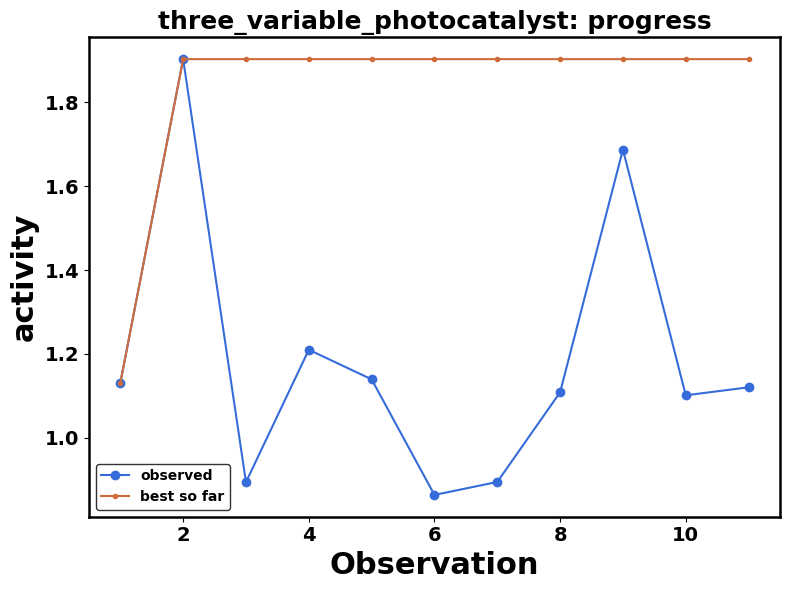

In [10]:
campaign.plot_progress(save_path=progress_path);

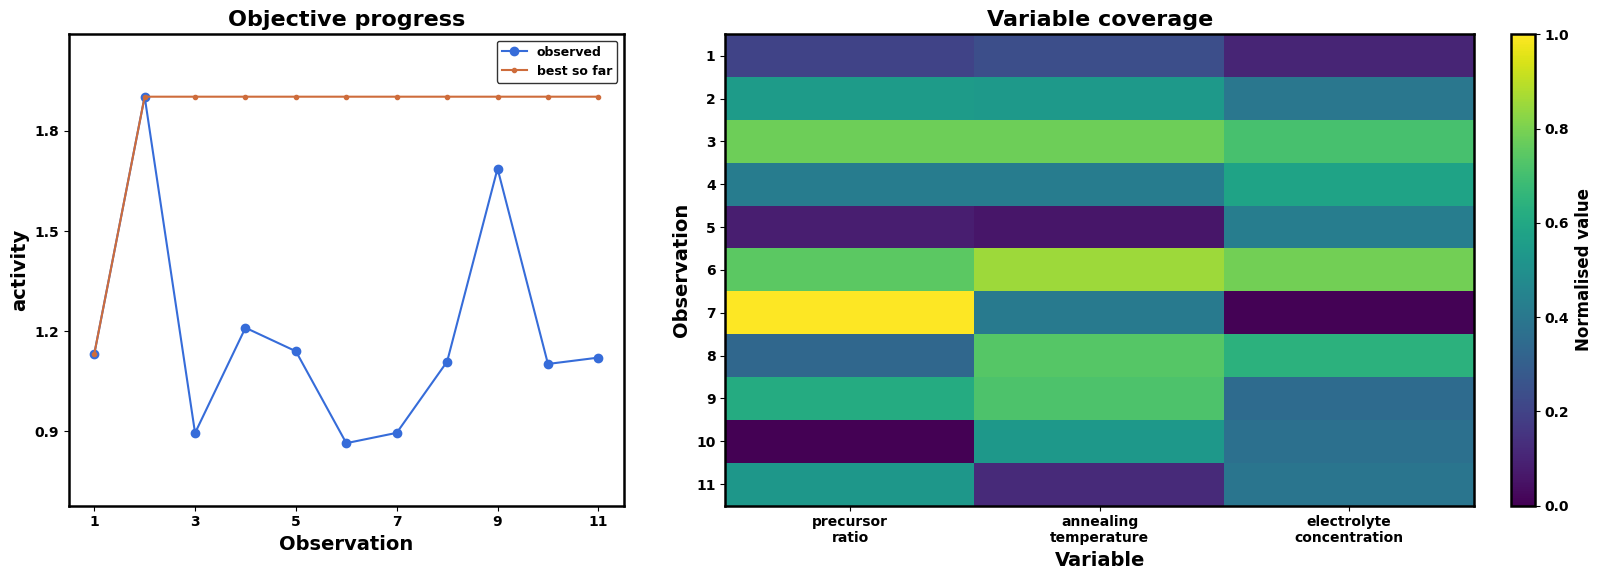

In [11]:
campaign.plot_diagnostics(save_path=diagnostics_path);